**Context**

Analysts are required to explore data and reflect on the insights. Clear writing skill is an integral part of a good report. Note that the explanations must be such that readers with minimum knowledge of analytics is able to grasp the insight.

Austo Motor Company is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.

**Objective**

They want to analyze the data to get a fair idea about the demand of customers which will help them in enhancing their customer experience. Suppose you are a Data Scientist at the company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

**Data Description**

*   Age: The age of the individual in years.
*   Gender: The gender of the individual, categorized as male or female.
*   Profession: The occupation or profession of the individual.
*   Marital_status: The marital status of the individual, such as married &, single
*   Education: The educational qualification of the individual Graduate and Post Graduate
*   No_of_Dependents: The number of dependents (e.g., children, elderly parents) that the individual supports financially.
*   Personal_loan: A binary variable indicating whether the individual has taken a personal loan "Yes" or "No"
*   House_loan: A binary variable indicating whether the individual has taken a housing loan "Yes" or "No"
*   Partner_working: A binary variable indicating whether the individual's partner is employed "Yes" or "No"
*   Salary: The individual's salary or income.
*   Partner_salary: The salary or income of the individual's partner, if applicable.
*   Total_salary: The total combined salary of the individual and their partner (if applicable).
*   Price: The price of a product or service.
*   Make: The type of automobile

**Importing the libraries**

In [ ]:
# importing all the libraries
import pandas as pd
import numpy as np

# libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to restrict the float value to 3 decimal places
pd.set_option('display.float_format',lambda x: '%.3f' % x)

# Command to tell Python to actually display the graphs
%matplotlib inline

**Loading the dataset**

In [ ]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv ('/content/drive/MyDrive/Colab Notebooks/austo_automobile .csv')

In [ ]:
# making a copy of the dataset
df = data.copy()

**Data Overview**

Let us start by performing the basic steps to understand the data such as:

*   Observing the first few rows of the dataset
*   Getting information about the number of rows and columns
*   Finding out the data types of the columns
*   Checking the statistical summary

In [ ]:
data.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.000,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.000,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.000,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.000,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.000,139900,57000,SUV


In [ ]:
data.tail()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.000,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.000,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback
1580,22,Male,Salaried,Married,Graduate,4,No,No,No,31600,0.000,31600,31000,Hatchback


In [ ]:
# checking the shape of the dataset
data.shape

(1581, 14)

*   *There are total 1581 rows and 14 columns in the dataset.*




In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


*   *There are total 6 columns which are numerical and rest are categorical in nature.*
*   *Observing the data seems there are missing values in 'Gender' and 'Partner_Salary'.*




In [ ]:
# Checking for any duplicate in the data
data.duplicated().sum()

np.int64(0)

*There are 0 duplicates in the data*

In [ ]:
# Checking for statistical summary of the data
data.describe()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000,1581.000,1581.000,1475.000,1581.000,1581.000
mean,31.922,2.458,60392.220,20225.559,79625.996,35597.723
std,8.426,0.943,14674.825,19573.149,25545.858,13633.637
min,22.000,0.000,30000.000,0.000,30000.000,18000.000
25%,25.000,2.000,51900.000,0.000,60500.000,25000.000
50%,29.000,2.000,59500.000,25600.000,78000.000,31000.000
75%,38.000,3.000,71800.000,38300.000,95900.000,47000.000
max,54.000,4.000,99300.000,80500.000,171000.000,70000.000


*   *The age of customers ranges between minimum 22 to maximum 54,average age of a vehicle-buying customer being approximately 31.*

*   *Customers typically have a maximum of four dependents.*

*   *The Total salary vary between minimum 30000 dollars to maximum 171000 dollars and the average salary is approximately 80000 dollars*.

*   *As per the data Vehicle prices range from a minimum of 18,000 dollars to a maximum of 70,000 dollars, average price of the vehicle is around 36000 dollars.*


In [ ]:
# checking the skewness for numerical column
# Select only numerical columns before computing the skewness
numerical_data = data.select_dtypes(include=np.number)
numerical_data.skew()

,0
Age,0.893
No_of_Dependents,-0.130
Salary,-0.012
Partner_salary,0.338
Total_salary,0.610
Price,0.741


**Lets check and treat missing values from the dataset**

In [ ]:
# checking missing values from the dataset
data.isnull().sum()

,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


*   *There are total 53 values are missing in Gender and 106 in Partners_Salary.*



**Checking the data consistency**

*   Also we have observed some wrong values in 'Gender' column lets correct the same.


In [ ]:
# checking the gender column as there were some wrong values in the data
data['Gender'].unique()

array(['Male', 'Femal', 'Female', nan, 'Femle'], dtype=object)

*There are total four values in the data*

In [ ]:
data['Gender'].value_counts()

,count
Gender,
Male,1199
Female,327
Femal,1
Femle,1


*We can see two false values which is 'Femal' and 'Femle' which needs to be treated.*

In [ ]:
# replacing two typo errors with correct fields
data['Gender'] = data['Gender'].replace('Femal', 'Female')
data['Gender'] = data['Gender'].replace('Femle', 'Female')

In [ ]:
data['Gender'].value_counts()

,count
Gender,
Male,1199
Female,329


In [ ]:
# checking why there is missing values in the gender column
data[data['Gender'].isnull()]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
24,46,NaN,Business,Married,Post Graduate,3,Yes,No,Yes,78000,600.000,78600,50000,SUV
25,46,NaN,Salaried,Married,Post Graduate,3,No,No,Yes,87900,700.000,88600,50000,SUV
67,53,NaN,Salaried,Married,Graduate,4,Yes,No,Yes,80900,30000.000,110900,49000,SUV
125,47,NaN,Salaried,Single,Post Graduate,2,Yes,No,No,87200,0.000,87200,49000,SUV
203,44,NaN,Salaried,Single,Post Graduate,0,Yes,No,No,68600,0.000,68600,50000,SUV
302,41,NaN,Salaried,Married,Graduate,1,Yes,No,No,55900,0.000,55900,32000,Sedan
325,40,NaN,Business,Married,Graduate,1,No,Yes,No,59600,0.000,59600,31000,Sedan
463,36,NaN,Salaried,Married,Post Graduate,3,Yes,No,No,66600,0.000,66600,49000,SUV
485,35,NaN,Business,Married,Post Graduate,2,Yes,Yes,Yes,61600,25000.000,86600,31000,Sedan
528,34,NaN,Salaried,Single,Post Graduate,2,No,Yes,No,64800,0.000,64800,32000,Sedan


*   *Its been observed that it does not have any relation with any other fields.*
*   *Gender can be treated using the mode option.*



In [ ]:
# Calculate the mode of the 'Gender' column
gender_mode = data['Gender'].mode()[0]
print(gender_mode)



Male


In [ ]:
# Fill missing values in the 'Gender' column with the calculated mode
data['Gender'].fillna(gender_mode, inplace=True)

/tmp/ipython-input-23-3528500674.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna(gender_mode, inplace=True)


In [ ]:
# lets check the gender data after calculated and replacing values with mode
data['Gender'].value_counts()

,count
Gender,
Male,1252
Female,329


*We have treated the missing values in gender by using mode which is highest frequency*

***Lets treat the missing values in the 'Partner_salary'***

*   *Its been observed that 'Partner_salary' mainly depend upon Salary, Total salary and working condition of the customer.*
*   *Where partner working condition as yes we can use the formula as total_ salary - salary = Partner_salary.*
*   *Where Partners working condition is mentioned as No we can proceed with updating as '0'*






In [ ]:
# Checking how many partner working and not working
data[data['Partner_salary'].isnull()==True].groupby('Partner_working').size()

,0
Partner_working,
No,90
Yes,16


In [ ]:
# Assigning 0 salary to partner salary where partner is working as 'No'
data.loc[data['Partner_working']=='No','Partner_salary']=0

In [ ]:
data[data['Partner_salary'].isnull()==True].shape

(16, 14)

In [ ]:
data[data['Partner_salary'].isnull()==True]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
43,52,Male,Salaried,Married,Post Graduate,3,No,No,Yes,87600,NaN,88200,51000,SUV
49,52,Female,Business,Married,Post Graduate,4,No,No,Yes,90300,NaN,170400,69000,SUV
59,54,Male,Salaried,Married,Graduate,3,Yes,No,Yes,80600,NaN,81000,51000,SUV
111,48,Female,Business,Married,Graduate,3,No,No,Yes,90300,NaN,161100,62000,SUV
209,43,Female,Salaried,Married,Graduate,4,Yes,No,Yes,53400,NaN,123900,64000,SUV
284,41,Female,Business,Married,Post Graduate,2,No,No,Yes,70500,NaN,105800,33000,Sedan
339,39,Male,Salaried,Married,Post Graduate,2,Yes,No,Yes,76800,NaN,115400,50000,Sedan
376,38,Male,Salaried,Married,Post Graduate,2,Yes,No,Yes,79000,NaN,117400,46000,Sedan
424,37,Female,Salaried,Married,Graduate,2,Yes,Yes,Yes,62000,NaN,100700,46000,Sedan
444,36,Male,Business,Married,Post Graduate,2,No,No,Yes,72300,NaN,112400,48000,Sedan


In [ ]:
# Filling missing partner salary using fourmula Partner_salary = Total_salary - Salary
data['Partner_salary'].fillna(data['Total_salary']-data['Salary'],inplace=True)

/tmp/ipython-input-29-632662373.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Partner_salary'].fillna(data['Total_salary']-data['Salary'],inplace=True)


In [ ]:
data[data['Partner_salary'].isnull()==True].shape

(0, 14)

In [ ]:
data.isnull().sum()

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


***We have treated the missing values and now our data is cleaned, We can proceed further with aur univariate analysis for the numerical columns using histplot and boxplot.***

**Univariate Analysis**

*Univariate Analysis of Age*

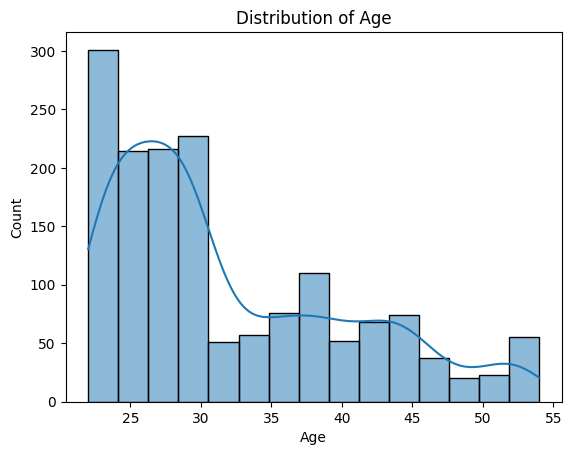

In [ ]:
# Using histplot for variable 'Age'
sns.histplot(data=data, x='Age', kde=True)
plt.xlabel('Age')
plt.title('Distribution of Age')
plt.show()

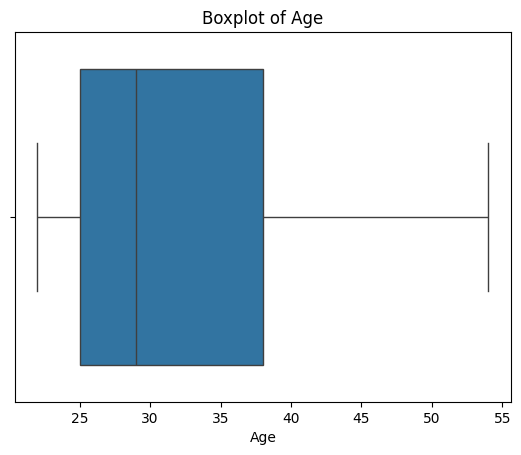

In [ ]:
# using boxplot for variable 'Age'
sns.boxplot(data=data, x='Age')
plt.xlabel('Age')
plt.title('Boxplot of Age')
plt.show()

**Observation on Age**

*   *The distribution is skewed to the right with no outliers.*
*   *The median age is around 29 and the maximum age is 54.*

**Univariate analysis of Salary**

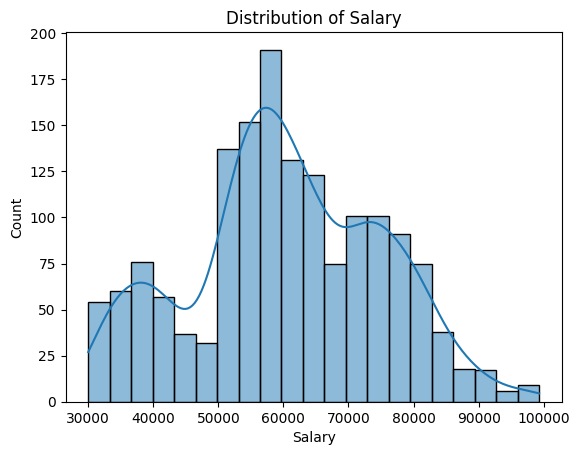

In [ ]:
# Using histplot for variable salary with kde
sns.histplot(data=data, x='Salary', kde=True)
plt.xlabel('Salary')
plt.title('Distribution of Salary')
plt.show()

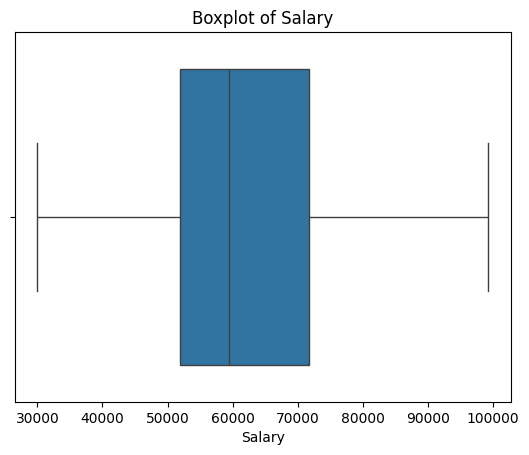

In [ ]:
# Using histplot for variable salary
sns.boxplot(data=data, x='Salary')
plt.xlabel('Salary')
plt.title('Boxplot of Salary')
plt.show()

**Observation on Salary**

*   *The distribution is balanced with no outliers.*
*   *The distribution is normal and median salary is around 59000 dollars and the maximum salary is around 99000 dollars.*

**Univariate analysis of Partners Salary**

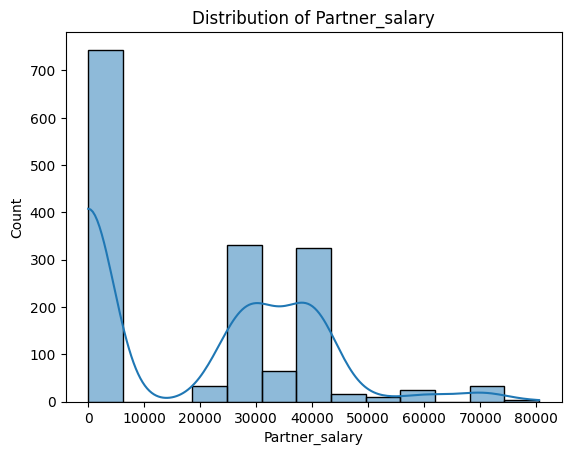

In [ ]:
# Using histplot for variable partners salary
sns.histplot(data=data, x='Partner_salary', kde=True)
plt.xlabel('Partner_salary')
plt.title('Distribution of Partner_salary')
plt.show()

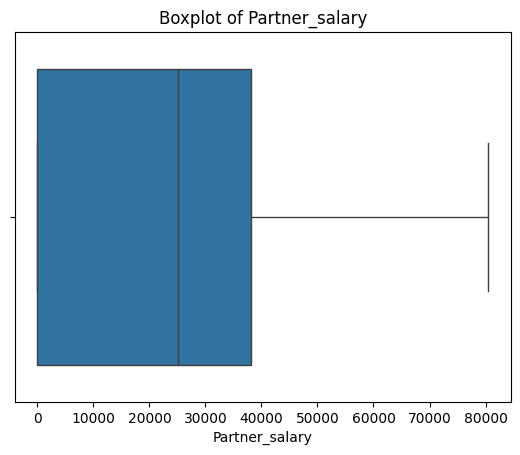

In [ ]:
# Using boxplot for for variable partners salary
sns.boxplot(data=data, x='Partner_salary')
plt.xlabel('Partner_salary')
plt.title('Boxplot of Partner_salary')
plt.show()

**Observation on Partner_Salary**

*   *The distribution is skewed to the right with no ouliers.*
*   *The median salary is around 25000 dollars and the maximum total salary is 80000 dollars.*

**Univariate analysis of Total_salary**

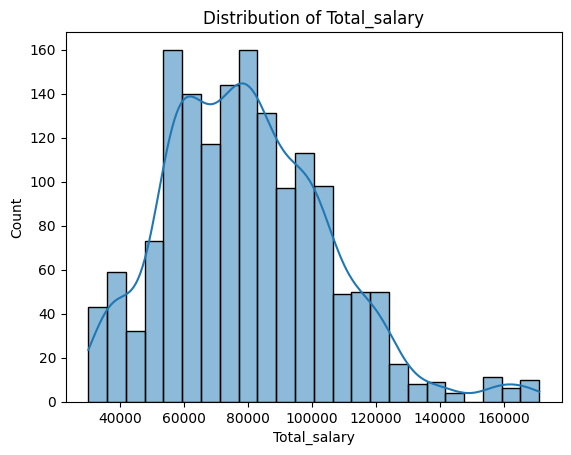

In [ ]:
# Using histplot for variable total salary
sns.histplot(data=data, x='Total_salary', kde=True)
plt.xlabel('Total_salary')
plt.title('Distribution of Total_salary')
plt.show()

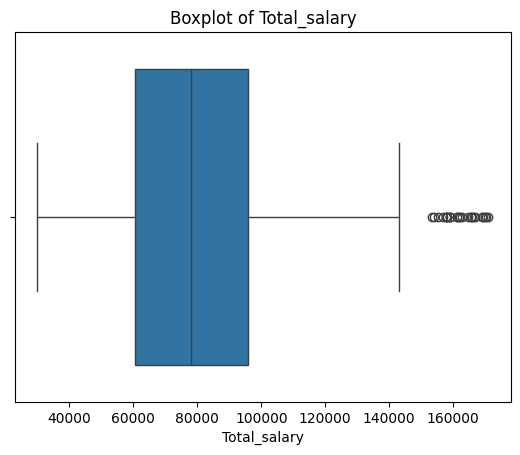

In [ ]:
# using boxplot for variable total salary
sns.boxplot(data=data, x='Total_salary')
plt.xlabel('Total_salary')
plt.title('Boxplot of Total_salary')
plt.show()

In [ ]:
# Investigating more on Total_Salary data
data.loc[data['Total_salary']>145000]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.000,170000,61000,SUV
1,53,Female,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.000,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.000,158000,57000,SUV
17,49,Female,Salaried,Married,Post Graduate,4,No,No,Yes,95100,70600.000,165700,64000,SUV
18,49,Female,Business,Married,Post Graduate,3,No,No,Yes,92600,70300.000,162900,58000,SUV
19,49,Male,Salaried,Married,Post Graduate,3,Yes,No,Yes,98400,60600.000,159000,54000,SUV
29,46,Female,Salaried,Married,Post Graduate,2,No,No,Yes,98300,70700.000,169000,61000,SUV
30,46,Male,Salaried,Married,Post Graduate,4,No,No,Yes,94900,70700.000,165600,67000,SUV
31,46,Male,Business,Married,Graduate,2,Yes,No,Yes,91100,70000.000,161100,66000,SUV
41,53,Female,Salaried,Married,Post Graduate,4,No,No,Yes,96600,70300.000,166900,66000,SUV


**Observation on Total Salary**

*  *The distribution is slighly skewed to the right and has some outliers*.
*  *Its been observed that the total salary is highly impacted due to individual salary and partners salary.*
*   *The median total salary is around 78000 dollars.*


**Univariate analysis of Price**

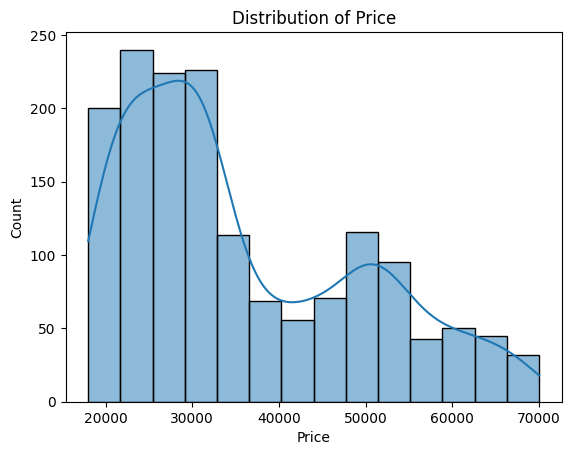

In [ ]:
# Using histplot for variable price
sns.histplot(data=data, x='Price', kde=True)
plt.xlabel('Price')
plt.title('Distribution of Price')
plt.show()

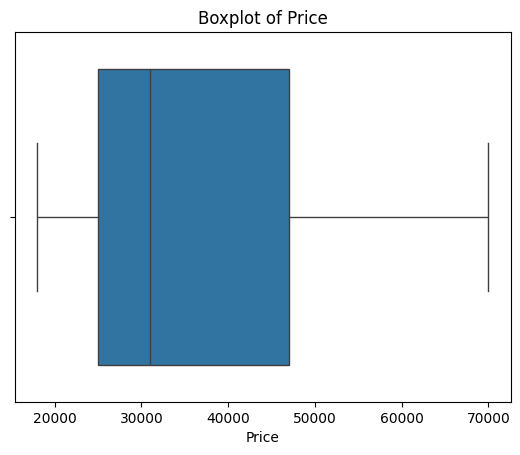

In [ ]:
# Using boxplot for variable price
sns.boxplot(data=data, x='Price')
plt.xlabel('Price')
plt.title('Boxplot of Price')
plt.show()

**Observation on Price**

*   *The distribution is skewed to the right with no outliers.*
*   *The median price is around 32000 dollars and maximum price is 70000 dollars.*

**Bivariate Analysis**

*Let's try to visualise how these numerical variables are associated with each other*

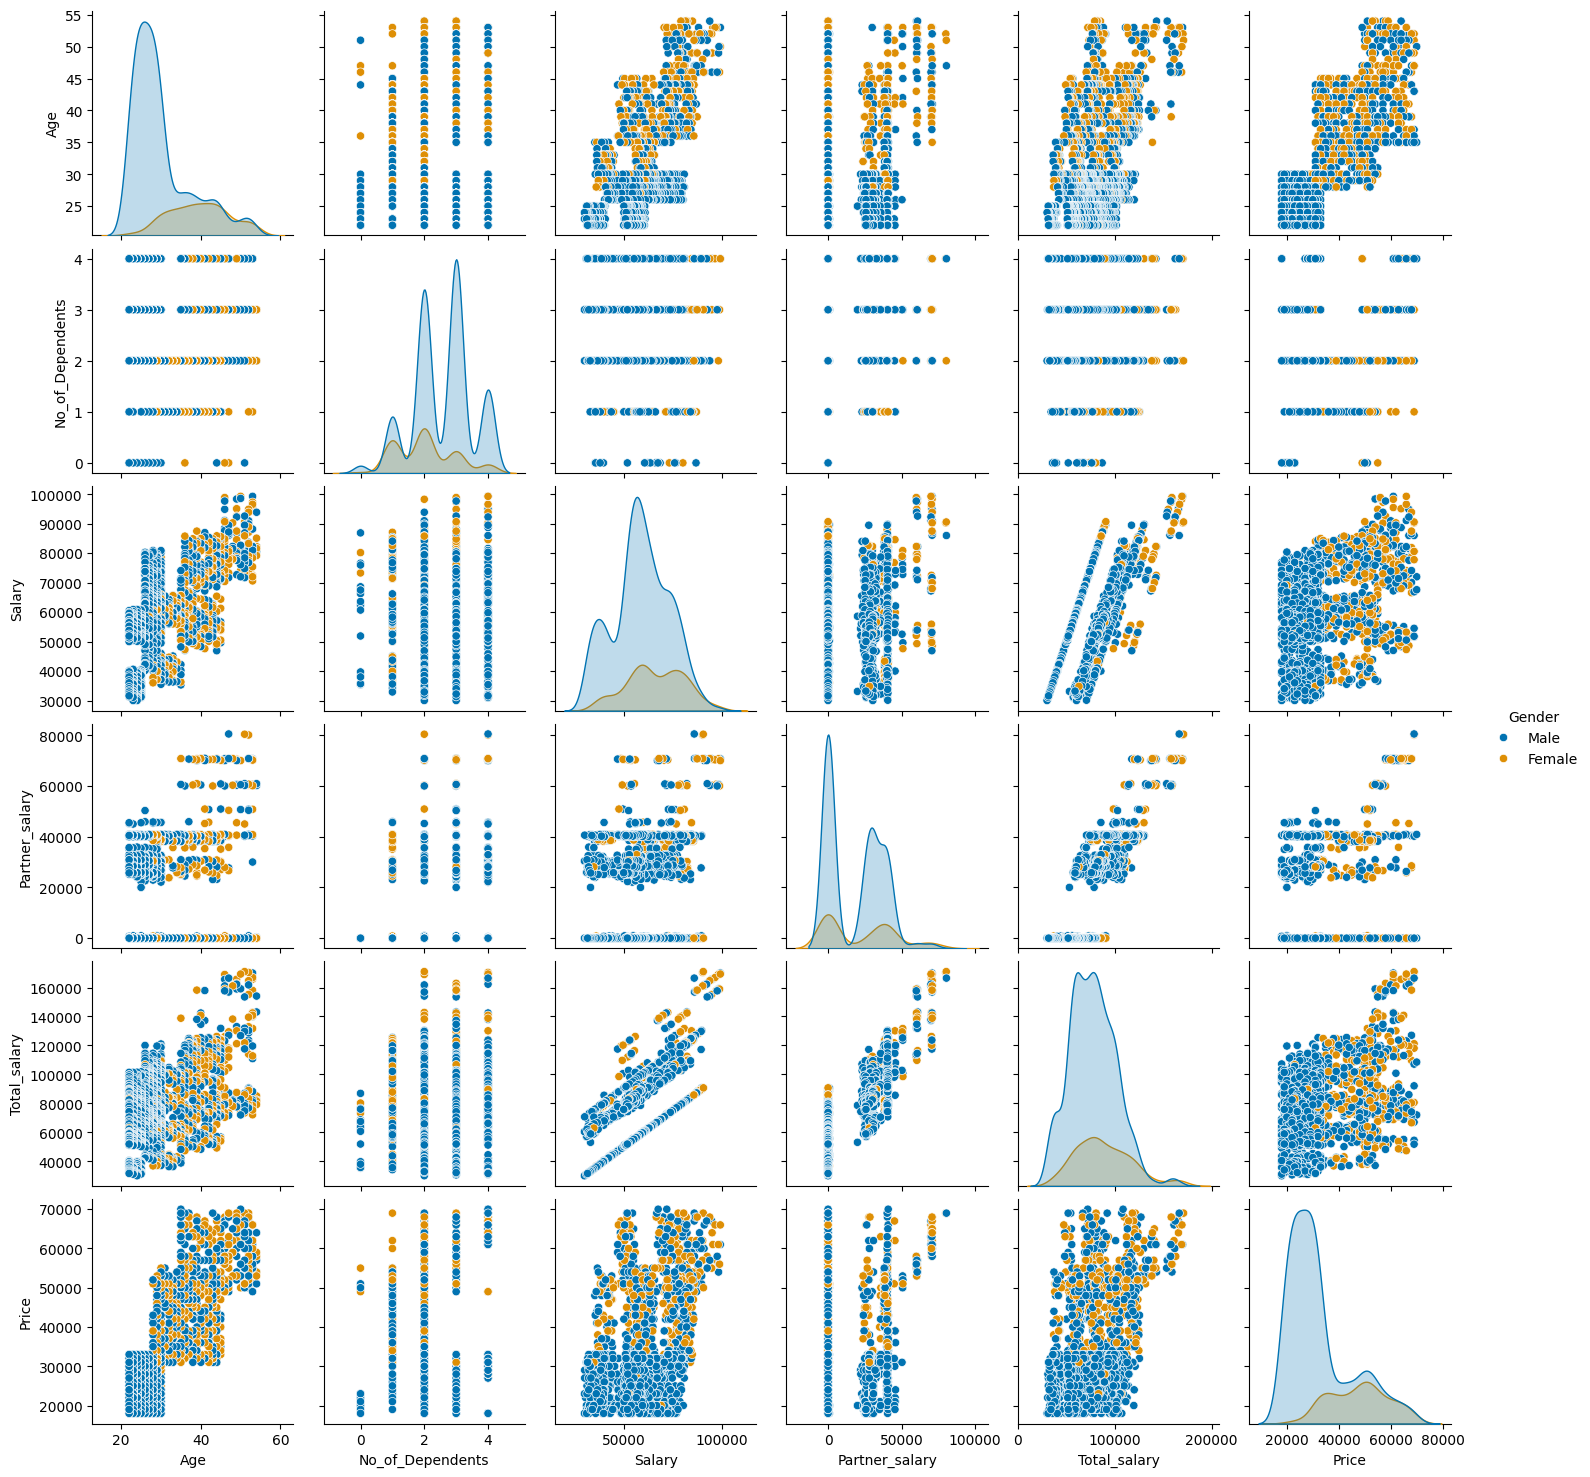

<Figure size 50x50 with 0 Axes>

In [ ]:
# lets check relationship between categorical and numerical variable using pairplot
sns.pairplot(data=data, hue='Gender', palette='colorblind')
plt.figure(figsize=(0.5,0.5))
plt.show()


In [ ]:
# lets compute the correlation matrix
numerical_data = data.select_dtypes(include=np.number)
correlation_matrix = numerical_data.corr()

# Display the correlation matrix
display(correlation_matrix)

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
Age,1.000,-0.190,0.617,0.136,0.459,0.798
No_of_Dependents,-0.190,1.000,-0.032,0.144,0.093,-0.136
Salary,0.617,-0.032,1.000,0.087,0.642,0.410
Partner_salary,0.136,0.144,0.087,1.000,0.820,0.172
Total_salary,0.459,0.093,0.642,0.820,1.000,0.368
Price,0.798,-0.136,0.410,0.172,0.368,1.000


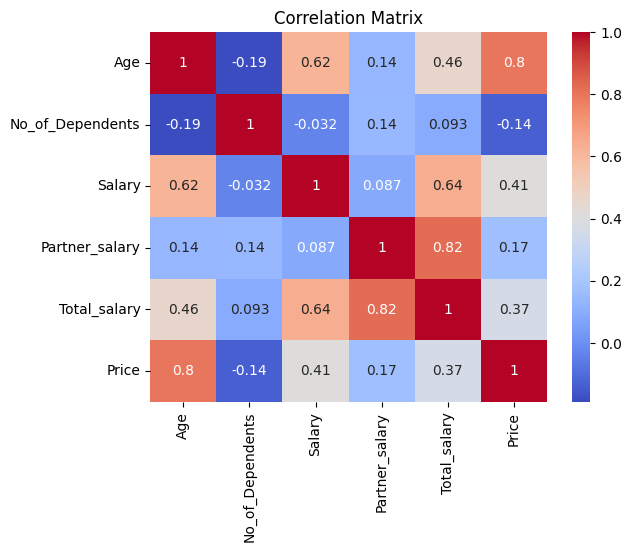

In [ ]:
# Lets use heatmap for the correlation matrix for the numerical variables
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Observation**
*   *The price and Age is highly positively correlated with the value 0.8.*
*   *Also secondly Total_Salary and Partner_Salary positively correlated with each other.*
*   *No_of_dependents are negetive correlated with price.*





Lets explore the data to answer the following key questions:


1.   **Do men tend to prefer SUVs more compared to women?**



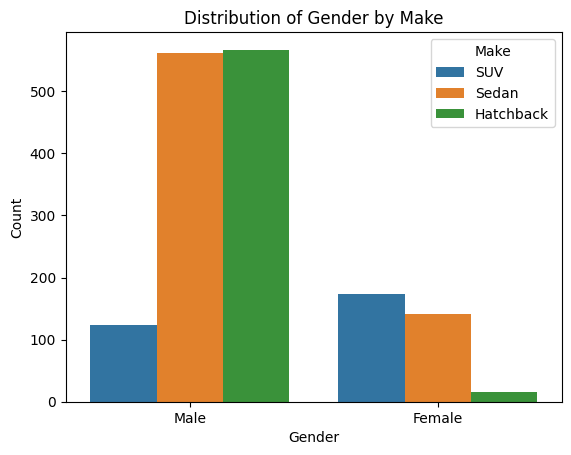

In [ ]:
# Lets check do men tend to prefer SUVs more compared to women?
# Using countplot for both the variables gender and make
sns.countplot(data=data, x='Gender', hue='Make')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender by Make')
plt.show()

In [ ]:
# Calculating the percentages for SUV purchases for both the genders
data[data['Make'] == 'SUV'].groupby('Gender').size() / data[data['Make'] == 'SUV'].shape[0] * 100


,0
Gender,
Female,58.249
Male,41.751


In [ ]:
# calculating the count of number of SUVs purchased by male and female
data[data['Make'] == 'SUV'].groupby('Gender').size()

,0
Gender,
Female,173
Male,124


**Observation**

*   *Men do not show a preference for SUVs, Its been observed that males are more tend to buy Hatchbacks followed by sedan.*
*  *Women purchasing the highest number of SUVs at 173 followed by sedan.*


2.   **What is the likelihood of a salaried person buying a Sedan?**



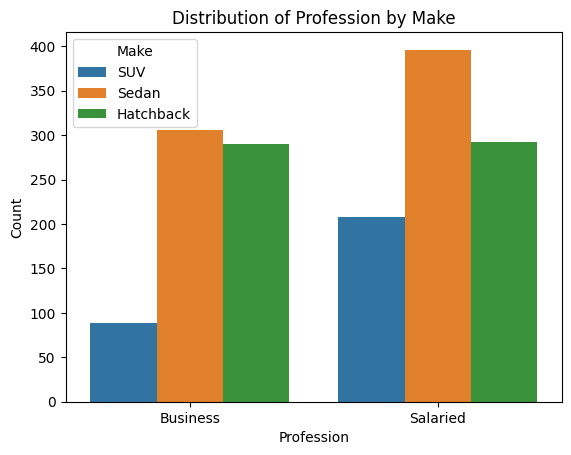

In [ ]:
# What is the likelihood of a salaried person buying a Sedan?
# Using countplot for profession and make
sns.countplot(data=data, x='Profession', hue='Make')
plt.xlabel('Profession')
plt.ylabel('Count')
plt.title('Distribution of Profession by Make')
plt.show()

In [ ]:
# Calculating the percentages of the proportion for car make purchase for salaried professionals
data[data['Profession'] == 'Salaried'].groupby('Make').size() / data[data['Profession'] == 'Salaried'].shape[0] * 100

,0
Make,
Hatchback,32.589
SUV,23.214
Sedan,44.196


In [ ]:
# lets calculate the number of count of salaried person to buy sedan
data[data['Make'] == 'Sedan'].groupby('Profession').size()

,0
Profession,
Business,306
Salaried,396


**Observation**

*   *The salaried prefessionals prefer to buy sedan as compare to business professionals with the percentage of 56%.*
*   *Also Hatchback is equally distributed among both the professionals.*
*   *Among buyers, salaried professionals constitute 23% of SUV purchasers, 32% of hatchback purchasers, and 44% of sedan purchasers.*



3. **What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?**

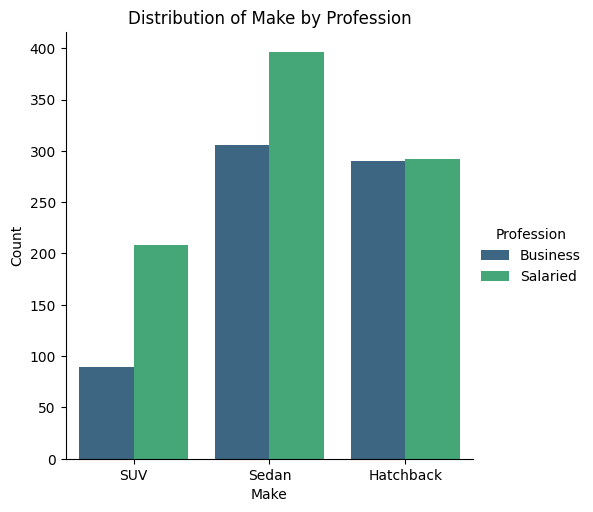

In [ ]:
# Lets calculate the purchase of cars amongst salaried buyers using catplot
sns.catplot(data=data, x='Make', hue='Profession', kind='count', palette='viridis')
plt.xlabel('Make')
plt.ylabel('Count')
plt.title('Distribution of Make by Profession')
plt.show()

**Observation**
*   *Our observations indicate that salaried professionals demonstrate a higher propensity to purchase sedans, with hatchbacks being their second preference. They show a lower likelihood of preferring SUVs.*


4.   **How does the the amount spent on purchasing automobiles vary by gender?**




In [ ]:
# Lets calculate the average amount as per the gender buying the automobiles
data.groupby('Gender')['Price'].mean()

,Price
Gender,
Female,47705.167
Male,32416.134


In [ ]:
# lets check highest amount spent spent by females on automobiles
data[data['Gender']=='Female']['Price'].max()

69000

In [ ]:
# Calculate the average price by gender
mean_price_by_gender = data.groupby('Gender')['Price'].mean()

# Calculate the overall mean price
overall_mean_price = data['Price'].mean()

# Calculate the percentage of the overall mean price for each gender
percentage_of_overall_mean = (mean_price_by_gender / overall_mean_price) * 100

print("Percentage of overall mean price by gender:")
print(percentage_of_overall_mean)

Percentage of overall mean price by gender:
Gender
Female   134.012
Male      91.062
Name: Price, dtype: float64


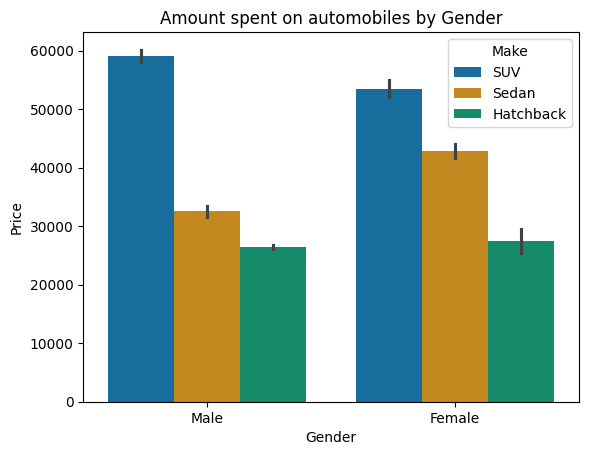

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
# lets compare amount spent on cars based on the gender using barplot
plt.title('Amount spent on automobiles by Gender')
sns.barplot(data=data, x='Gender', y='Price', hue='Make', palette='colorblind')
plt.show()
plt.figure(figsize=(10, 6))





/tmp/ipython-input-57-1404924886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Gender', y='Price',palette='colorblind')


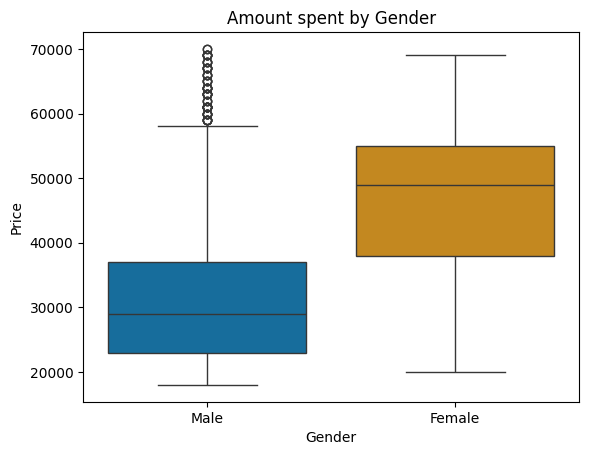

In [ ]:
# How does the the amount spent on purchasing automobiles vary by gender?
# lets calculate the amount spent by gender using boxplot
sns.boxplot(data=data, x='Gender', y='Price',palette='colorblind')
plt.xlabel('Gender')
plt.ylabel('Price')
plt.title('Amount spent by Gender')
plt.show()

**Observation**
*   *Females tend to spend significantly more on automobiles than men, with an observed average of 134% higher spending.*
*   *Observed few outliers on mele spending on automobiles.*
*   *The median amount spent is 28000 dollars for males and 48000 dollars for females.*
*   *Females tend to spend more on SUVs, followed by sedans.*
*   *Males are more inclined to buy SUVs than females.*










5.   **How much money was spent on purchasing automobiles by individuals who took a personal loan?**




In [ ]:
# lets calculate the statistics of personal loan and price
data.groupby('Personal_loan')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Personal_loan,,,,,,,,
No,789.000,36742.712,14534.345,18000.000,25000.000,32000.000,49000.000,70000.000
Yes,792.000,34457.071,12578.780,18000.000,24000.000,31000.000,45000.000,70000.000


/tmp/ipython-input-59-1332536253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Personal_loan', y='Price',palette='colorblind')


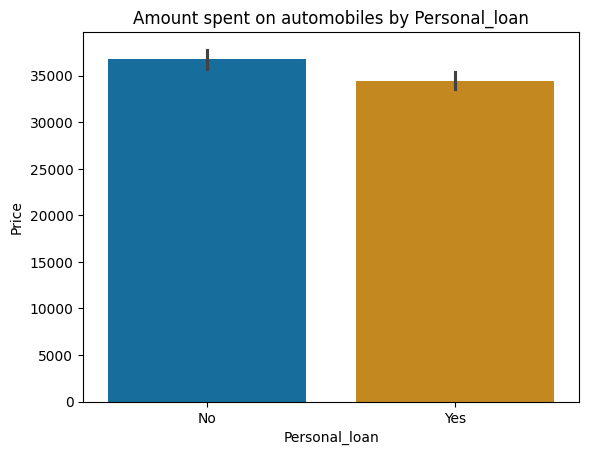

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
# lets check the amount spent on purchasing automobiles by the individual who took personal loan by using bar plot
plt.title('Amount spent on automobiles by Personal_loan')
sns.barplot(data=data, x='Personal_loan', y='Price',palette='colorblind')
plt.show()
plt.figure(figsize=(10, 6))


/tmp/ipython-input-60-2818940673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Personal_loan', y='Price',palette='colorblind')


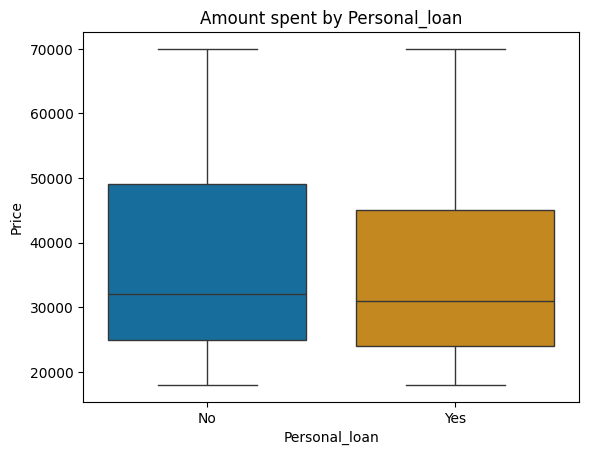

In [ ]:
# Lets check the amount spent on automobiles by individual who took personal loan by using boxplot
sns.boxplot(data=data, x='Personal_loan', y='Price',palette='colorblind')
plt.xlabel('Personal_loan')
plt.ylabel('Price')
plt.title('Amount spent by Personal_loan')
plt.show()

**Observation**

*   *Its been highly observed that there is not much diffrence to be seen in purchasing limit based on the individual who took personal loan or not.*
*   *The numbers are slightly high towards the individual who did not took any personal loan.*
*   *The average amount spent is around 37000 dollars who did not took any personal loan however its around 15000 dollars who took the loan.*
*   *There are no outliers.*







6. **How does having a working partner influence the purchase of higher-priced cars?**

In [ ]:
# lets calculate the mean median and mode of working partner using describe
data.groupby('Partner_working')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Partner_working,,,,,,,,
No,713.000,36000.000,13817.734,18000.000,25000.000,31000.000,48000.000,70000.000
Yes,868.000,35267.281,13479.533,18000.000,24000.000,31000.000,46000.000,70000.000


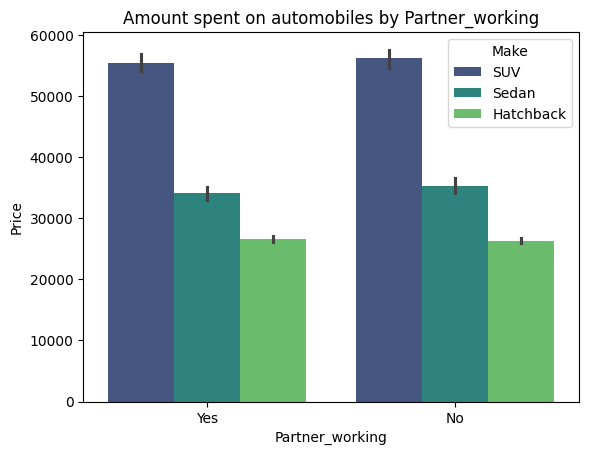

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
# lets compare working partner with high priced cars using stacked bar chart
plt.title('Amount spent on automobiles by Partner_working')
sns.barplot(data=data, x='Partner_working', y='Price',hue='Make',palette='viridis')
plt.show()
plt.figure(figsize=(10, 6))

/tmp/ipython-input-63-1714991970.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Partner_working', y='Price',palette='viridis')


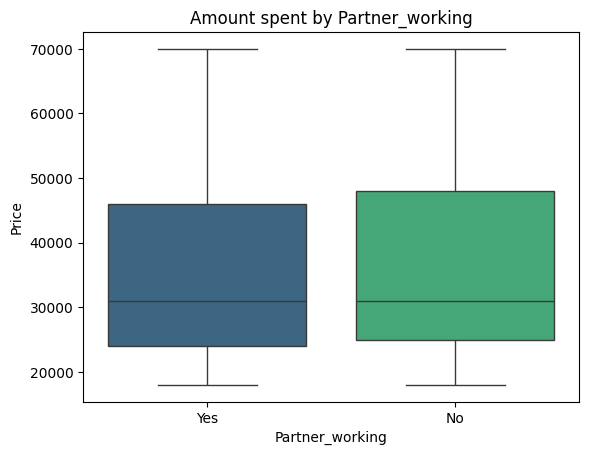

In [ ]:
# Lets analyse more how partner working influence high priced cars using boxplot
sns.boxplot(data=data, x='Partner_working', y='Price',palette='viridis')
plt.xlabel('Partner_working')
plt.ylabel('Price')
plt.title('Amount spent by Partner_working')
plt.show()

**Observation**
*   *Its been highly observed that Partner working condition does not have much impact on  purchase of high priced cars.*
*   *There are no outliers.*





**Actionable Insights and Recommendations from the data**

1. **Do men tend to prefer SUVs more compared to women?**

*Actionable Insight*-
*   We have identified that Males did not showed a preference to buy SUVs however they are more tend to buy Hatchbacks followed by Sedan it is suggested that marketing efforts and sales strategies specifically targeting male consumers might be misaligned if they heavily emphasize SUVs. There's a clear opportunity to reallocate marketing budgets and tailor promotional content to spotlight the benefits of Hatchbacks and Sedans

*Recommendation* -
*   Tailor promotional content (focusing on specific benefits of Hatchbacks/Sedans) and for women ( On SUVs )






2. **What is the likelihood of a salaried person buying a Sedan?**

*Actionable Insight-*

Our analysis reavels that out of 56% of the salaried individuals preferred to buy sedans than business professionals This indicates that our current sedan marketing and product positioning effectively resonate with the lifestyle, commuting needs, and budget considerations of salaried individuals, presenting a prime opportunity to double down on marketing efforts for sedans specifically tailored to this high-conversion segment.

*Recommendations -*
*   Develop and launch targeted digital and traditional marketing campaigns (e.g., social media ads, email marketing, print ads in relevant publications/websites) specifically highlighting sedan features that appeal most to salaried individuals.
*   Conduct training for sales teams to educate them on the distinct preferences and common pain points of salaried professionals when considering car purchases.
*   Explore partnerships with large corporations, professional associations, or public sector organizations that employ a high number of salaried professionals. Offer exclusive corporate discounts, preferred financing rates, or special service packages on sedans for their employees. Participate in corporate events, job fairs, or online forums popular among this group.







3. **What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?**

*Actionable insight*-
*   Our analysis shows that salaried professionals prioritize sedans followed by hatchbacks They show a lower likelihood of preferring SUVs, it is suggested that reallocate resources and intensify marketing for sedans and hatchbacks specifically targeting salaried professionals.

*Recommendations*-
*   Reallocate Marketing Budget & Focus to Sedans and Hatchbacks targetting salaried professionals.
*   Develop Tailored Messaging & Content for Salaried Lifestyles by creating marketing collateral, ad copy, and social media content that directly speaks to the daily life and aspirations of salaried individuals.
*   We can also Optimize Inventory and Showroom Presentation by ensuring that dealerships maintain robust inventory levels of popular sedan and hatchback models and variants that appeal to salaried buyers.

4. **How does the the amount spent on purchasing automobiles vary by gender?**

*Actionable insight*-

*   Our analysis reveals that women represent an exceptionally high-value segment in automobile purchases, spending an average of 134% more than men. It is suggested to re-evaluate our offerings, messaging, and sales approach to better align with the factors driving this higher spending by women.

*Recommendation*-


*   Develop Targeted and Empowering Marketing Campaigns for females buyers.
*   We can also Tailor Product Offerings and Showroom Experience to Female Preferences ensuring that vehicle with safety and specific body types (like SUVs, as previously identified) that contribute to higher spending are prominently featured in marketing and readily available in inventory.

5. **How much money was spent on purchasing automobiles by individuals who took a personal loan?**

*Actionable Insight-*
*   Individuals who took personal loan tend to spend average amount which is 36000 dollars and maximum 45000 dollars on automobiles.

*Recommendations-*
*   We can optimize Inventory and Promotions for the 35,000 dollars - 45,000 dollars Price Segment.
*   We can also Collaborate with financing partners to offer highly competitive auto loan rates, flexible payment structures, or perhaps even deferred payment options specifically designed for customers who may already be managing personal loan debt.






6. **How does having a working partner influence the purchase of higher-priced cars?**

*Actionable Insight-*
*   Analysis reveals that the presence of a working partner has minimal impact on the likelihood of purchasing high-priced automobiles.

*Recommendations-*
*   We can consider prioritizing high value customer segments which is profession and gender as partner working condition is not a strong predictor for identifying potential high-priced car buyers.



